In [2]:
import re
import os
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
from typing import Union
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans


In [3]:
seed = 42
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
PRITHVI_START = "1980-01-01"
PRITHVI_END   = "2021-12-31"
daily_index = pd.date_range(PRITHVI_START, PRITHVI_END, freq="D")

sst_path = Path("climate_indices_data/sst_weekly.txt")
mjo_path = Path("climate_indices_data/mjo.txt")
nino34_path = Path("climate_indices_data/nino34_daily.csv")
iod_path = Path("climate_indices_data/iod_daily.csv")

print("SST file:", sst_path)
print("MJO file:", mjo_path)
print("Nino34 file:", nino34_path)
print("IOD Path:", iod_path)

SST file: climate_indices_data/sst_weekly.txt
MJO file: climate_indices_data/mjo.txt
Nino34 file: climate_indices_data/nino34_daily.csv
IOD Path: climate_indices_data/iod_daily.csv


### SST: read weekly Niño3.4 SSTA

In [154]:
# def read_sst_weekly_nino34_ssta(sst_path: Union[str, Path]) -> pd.Series:
#     sst_path = Path(sst_path)
#     lines = sst_path.read_text().splitlines()

#     date_pat = re.compile(r"^\d{2}[A-Za-z]{3}\d{4}$")  # e.g., 02SEP1981

#     def parse_ssta(token: str) -> float:
#         token = token.strip()
#         nums = re.findall(r"[+-]?\d+(?:\.\d+)?", token)
#         if len(nums) >= 2:
#             return float(nums[1])  # second number is SSTA
#         return np.nan

#     rows = []
#     for line in lines:
#         line = line.strip()
#         if not line or line.startswith("#"):
#             continue

#         parts = line.split()
#         if len(parts) < 5:
#             continue

#         if not date_pat.match(parts[0]):
#             continue

#         dt = pd.to_datetime(parts[0], format="%d%b%Y", errors="coerce")
#         if pd.isna(dt):
#             continue

#         # date, Nino12, Nino3, Nino34, Nino4
#         nino34_token = parts[3]
#         ssta = parse_ssta(nino34_token)
#         rows.append((dt, ssta))

#     if not rows:
#         raise ValueError(
#             f"No valid SST rows parsed from {sst_path}. "
#             "Check that file has data lines starting with dates like 02SEP1981."
#         )

#     s = pd.Series([v for _, v in rows], index=[d for d, _ in rows], name="nino34_ssta")
#     s = s.sort_index().astype("float32")
#     return s

# sst_ssta = read_sst_weekly_nino34_ssta(sst_path)
# print("SST range:", sst_ssta.index.min(), "->", sst_ssta.index.max())
# print("NaN frac:", float(sst_ssta.isna().mean()))
# print(sst_ssta.head())

In [10]:
def read_sst_weekly_nino34_ssta(sst_path: Union[str, Path]) -> pd.Series:
    sst_path = Path(sst_path)
    lines = sst_path.read_text().splitlines()

    date_pat = re.compile(r"^\d{2}[A-Za-z]{3}\d{4}$")  # e.g. 02SEP1981

    rows = []
    for line in lines:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split(maxsplit=1)
        if len(parts) < 2:
            continue

        date_str, rest = parts[0], parts[1]

        if not date_pat.match(date_str):
            continue

        dt = pd.to_datetime(date_str, format="%d%b%Y", errors="coerce")
        if pd.isna(dt):
            continue

        nums = re.findall(r"[+-]?\d+\.\d+", rest)

        if len(nums) < 6:
            rows.append((dt, np.nan))
            continue

        nino34_ssta = float(nums[5])
        rows.append((dt, nino34_ssta))

    if not rows:
        raise ValueError(
            f"No valid SST rows parsed from {sst_path}. "
            "Check that file has data lines starting with dates like 02SEP1981."
        )

    s = pd.Series([v for _, v in rows], index=[d for d, _ in rows], name="nino34_ssta")
    s = s.sort_index().astype("float32")
    return s
sst_ssta = read_sst_weekly_nino34_ssta(sst_path)
print("SST range:", sst_ssta.index.min(), "->", sst_ssta.index.max())
print("NaN frac:", float(sst_ssta.isna().mean()))
print(sst_ssta.head())

SST range: 1981-09-02 00:00:00 -> 2026-01-07 00:00:00
NaN frac: 0.0
1981-09-02   -0.2
1981-09-09   -0.2
1981-09-16   -0.2
1981-09-23   -0.5
1981-09-30   -0.4
Name: nino34_ssta, dtype: float32


### nino34 daily data

In [5]:
nino34_df = pd.read_csv(nino34_path)
nino34_df.head()

,time,anom
0,1981-09-01,-0.033502
1,1981-09-02,-0.045651
2,1981-09-03,-0.089332
3,1981-09-04,-0.278631
4,1981-09-05,-0.333117


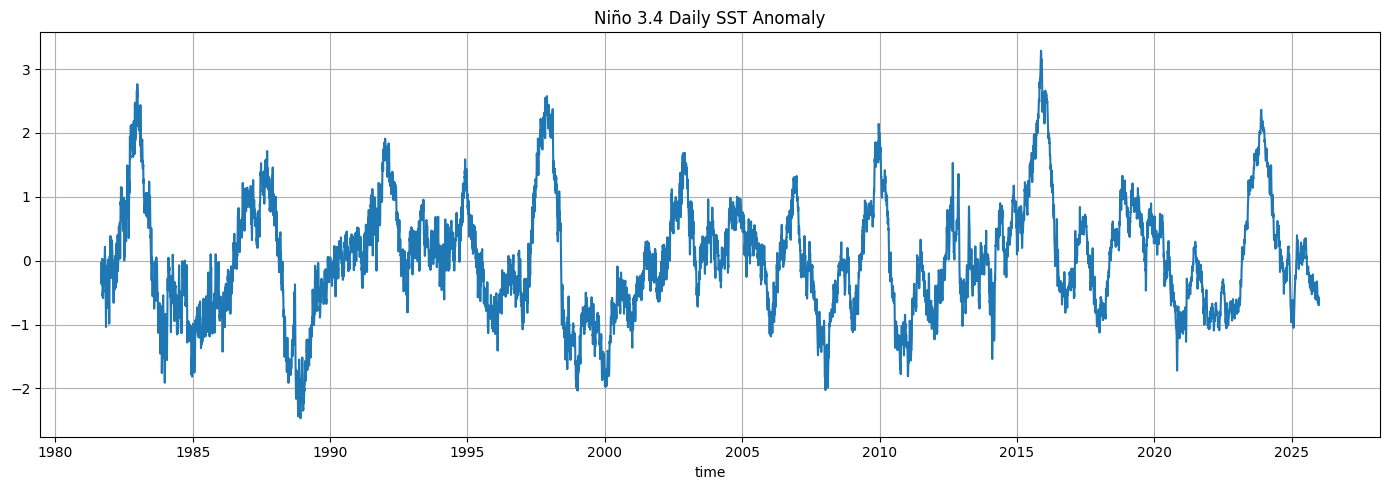

In [6]:
nino34_df["time"] = pd.to_datetime(nino34_df["time"])
plt.figure(figsize=(14, 5))
plt.plot(nino34_df["time"], nino34_df["anom"])
plt.title("Niño 3.4 Daily SST Anomaly")
plt.xlabel("time")
plt.ylabel("")
plt.grid(True)
plt.tight_layout()
plt.show()

### IOD Daily Data

In [7]:
iod_df = pd.read_csv(iod_path)
iod_df.head()

,time,anom
0,1981-09-01,0.018197
1,1981-09-02,-0.216944
2,1981-09-03,-0.203128
3,1981-09-04,-0.176097
4,1981-09-05,-0.277731


### MJO: read daily RMM1 / RMM2 / amplitude

In [8]:
#parse MJO file: build daily time series for RMM1/RMM2/AMP, then align
def read_mjo(path: Path) -> pd.DataFrame:
    """
    Reads mjo.txt assuming 2 header lines to skip (your file has text headers).
    Columns expected: year month day RMM1 RMM2 phase amplitude ...
    """
    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=2,
        header=None,
        usecols=[0,1,2,3,4,6],  # year,month,day,rmm1,rmm2,amp (phase is col5)
        names=["year","month","day","rmm1","rmm2","amp"],
        engine="python"
    )
    for c in ["year","month","day","rmm1","rmm2","amp"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=df.day), errors="coerce")
    df = df.dropna(subset=["date"]).set_index("date").sort_index()

    # Fix missing sentinels if present (common in these files)
    df = df.replace({999: np.nan, 999.0: np.nan, 1e36: np.nan, 1e36+0.0: np.nan})
    return df[["rmm1","rmm2","amp"]].astype("float32")

mjo_df = read_mjo(mjo_path)
print(mjo_df.head())
print("MJO series:", mjo_df.index.min(), "→", mjo_df.index.max(), "NaN frac:", float(mjo_df.isna().mean().mean()))

               rmm1     rmm2      amp
date                                 
1974-06-01  1.63447  1.20304  2.02948
1974-06-02  1.60289  1.01512  1.89729
1974-06-03  1.51625  1.08551  1.86476
1974-06-04  1.50981  1.03573  1.83092
1974-06-05  1.55906  1.30518  2.03326
MJO series: 1974-06-01 00:00:00 → 2026-01-13 00:00:00 NaN frac: 0.0


In [9]:
# Clip MJO to the Prithvi period and reindex to a complete daily grid
mjo_daily = (
    mjo_df
    .reindex(daily_index)
    .interpolate(method="time", limit=3, limit_direction="both")
    .astype("float32")
)
mjo_daily.index.name = "time"

print(f"Daily MJO shape: {mjo_daily.shape}")
print(f"Range: {mjo_daily.index.min()} → {mjo_daily.index.max()}")
print(f"NaN count per col:\n{mjo_daily.isna().sum()}")
mjo_daily.head(10)

Daily MJO shape: (15341, 3)
Range: 1980-01-01 00:00:00 → 2021-12-31 00:00:00
NaN count per col:
rmm1    0
rmm2    0
amp     0
dtype: int64


,rmm1,rmm2,amp
time,,,
1980-01-01,0.811586,-0.066468,0.814303
1980-01-02,0.705088,-0.029684,0.705712
1980-01-03,0.662733,0.037199,0.663776
1980-01-04,0.614840,0.213630,0.650896
1980-01-05,0.702877,0.490769,0.857257
1980-01-06,0.758704,0.604175,0.969876
1980-01-07,0.674902,0.379001,0.774037
1980-01-08,0.764337,0.197338,0.789400
1980-01-09,0.795880,0.209051,0.822878


### Prepare Encoder and Decoder

In [10]:
latent_base = Path("latent_output_42years")

def load_latent_files(latent_dir, prefix):
    files = sorted(latent_dir.glob(f"{prefix}_*.npy"))
    vectors = [np.load(f) for f in files]
    times = pd.to_datetime([f.stem.replace(f"{prefix}_", "") for f in files])
    mask = (times.month >= 5) & (times.month <= 8)
    vectors = [v for v, keep in zip(vectors, mask) if keep]
    times = times[mask]
    return np.stack(vectors, axis=0), times

all_e, all_d, all_times, year_labels = [], [], [], []
year_dirs = sorted([d for d in latent_base.iterdir() if d.is_dir() and d.name.isdigit()])
for year_dir in year_dirs:
    arr_e, times_e = load_latent_files(year_dir, "encoder")
    arr_d, times_d = load_latent_files(year_dir, "decoder")
    assert times_e.equals(times_d), f"Encoder and decoder timestamps don't match in {year_dir}!"
    year = int(year_dir.name)
    all_e.append(arr_e)
    all_d.append(arr_d)
    all_times.append(times_e)
    year_labels.extend([year] * len(times_e))

latent_array_e = np.vstack(all_e)
latent_array_d = np.vstack(all_d)
latent_times = pd.DatetimeIndex(np.concatenate([t.values for t in all_times]))
year_labels = np.array(year_labels)


print("Encoder latent shape:", latent_array_e.shape)
print("Decoder latent shape:", latent_array_d.shape)
print("Years:", sorted(np.unique(year_labels)))
print("Year range:", latent_times[0], "to", latent_times[-1])

Encoder latent shape: (2267, 2560)
Decoder latent shape: (2267, 2560)
Years: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Year range: 1980-05-01 12:00:00 to 2020-08-31 12:00:00


In [11]:
# Align latent data with MJO and Niño3.4 (ENSO) by (year, month, day)
latent_dates = latent_times.normalize()
mjo_target = mjo_daily.loc[latent_dates][["rmm1", "rmm2"]]
nino_target = nino34_df.set_index("time")
nino_target = nino_target.reindex(daily_index)
nino_target = nino_target.loc[latent_dates][["anom"]]
mjo_target.head()

,rmm1,rmm2
1980-05-01,-0.668830,-0.20614
1980-05-02,-0.493520,-0.28857
1980-05-03,-0.177220,-0.37255
1980-05-04,-0.018511,-0.36817
1980-05-05,0.143794,-0.36287


In [12]:
y_rmm1 = mjo_target["rmm1"].values
y_rmm2 = mjo_target["rmm2"].values
y_nino = nino_target["anom"].values

### LSTM

In [92]:
class LSTM(nn.Module):
    def __init__(self, latent_dim, hidden_dim, num_layers, output_dim, dropout_rate=0.1):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim // 2, hidden_dim//4),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim//4, output_dim)
        )

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        predictions = self.fc(last_time_step)
        return predictions

In [139]:
# sequence preprocessing
year_use = (2007,2008,2009,2010,2011,2012,2013,2014, 2015, 2016, 2017, 2018, 2019, 2020)
seq_len = 1
def make_sequences(X, y, years, seq_len):
    X_seq, y_seq, seq_years = [], [], []
    for yr in np.unique(years):
        idx = np.where(years == yr)[0]
        X_year = X[idx]
        y_year = y[idx]
        for i in range(len(X_year) - seq_len):
            X_seq.append(X_year[i:i+seq_len])
            y_seq.append(y_year[i+seq_len])
            seq_years.append(yr)
    return np.array(X_seq), np.array(y_seq), np.array(seq_years)

year_mask_rmm = np.isin(year_labels, year_use)
years_rmm = year_labels[year_mask_rmm]
X_e_rmm = latent_array_e[year_mask_rmm]
X_d_rmm = latent_array_d[year_mask_rmm]
y_rmm1_use = y_rmm1[year_mask_rmm]
y_rmm2_use = y_rmm2[year_mask_rmm]
X_e_seq_rmm1, y_seq_rmm1, seq_years_rmm = make_sequences(
    X_e_rmm, y_rmm1_use, years_rmm, seq_len
)
X_e_seq_rmm2, y_seq_rmm2, _ = make_sequences(
    X_e_rmm, y_rmm2_use, years_rmm, seq_len
)

X_d_seq_rmm1, _, _ = make_sequences(
    X_d_rmm, y_rmm1_use, years_rmm, seq_len
)
X_d_seq_rmm2, _, _ = make_sequences(
    X_d_rmm, y_rmm2_use, years_rmm, seq_len
)

print("RMM1 encoder:", X_e_seq_rmm1.shape, y_seq_rmm1.shape, seq_years_rmm.shape)
print("RMM2 encoder:", X_e_seq_rmm2.shape, y_seq_rmm2.shape)
print("RMM1 decoder:", X_d_seq_rmm1.shape)
print("RMM2 decoder:", X_d_seq_rmm2.shape)

# from sklearn.decomposition import PCA

# # sequence preprocessing
# n_pcs = 20   # change this if you want

# def make_sequences(X, y, years, seq_len):
#     X_seq, y_seq, seq_years = [], [], []
#     for yr in np.unique(years):
#         idx = np.where(years == yr)[0]
#         X_year = X[idx]
#         y_year = y[idx]
#         for i in range(len(X_year) - seq_len):
#             X_seq.append(X_year[i:i+seq_len])
#             y_seq.append(y_year[i+seq_len])
#             seq_years.append(yr)
#     return np.array(X_seq), np.array(y_seq), np.array(seq_years)

# year_mask_rmm = np.isin(year_labels, year_use)
# years_rmm = year_labels[year_mask_rmm]

# X_e_rmm = latent_array_e[year_mask_rmm]
# X_d_rmm = latent_array_d[year_mask_rmm]

# y_rmm1_use = y_rmm1[year_mask_rmm]
# y_rmm2_use = y_rmm2[year_mask_rmm]

# # flatten latent vectors if needed
# X_e_rmm_flat = X_e_rmm.reshape(X_e_rmm.shape[0], -1)
# X_d_rmm_flat = X_d_rmm.reshape(X_d_rmm.shape[0], -1)

# # PCA on encoder latent vectors
# pca_e = PCA(n_components=n_pcs)
# X_e_rmm_pca = pca_e.fit_transform(X_e_rmm_flat)

# # PCA on decoder latent vectors
# pca_d = PCA(n_components=n_pcs)
# X_d_rmm_pca = pca_d.fit_transform(X_d_rmm_flat)

# # build sequences for RMM1
# X_e_seq_rmm1, y_seq_rmm1, seq_years_rmm = make_sequences(
#     X_e_rmm_pca, y_rmm1_use, years_rmm, seq_len
# )
# X_d_seq_rmm1, _, _ = make_sequences(
#     X_d_rmm_pca, y_rmm1_use, years_rmm, seq_len
# )

# # build sequences for RMM2
# X_e_seq_rmm2, y_seq_rmm2, _ = make_sequences(
#     X_e_rmm_pca, y_rmm2_use, years_rmm, seq_len
# )
# X_d_seq_rmm2, _, _ = make_sequences(
#     X_d_rmm_pca, y_rmm2_use, years_rmm, seq_len
# )

# print("Encoder PCA shape:", X_e_rmm_pca.shape)
# print("Decoder PCA shape:", X_d_rmm_pca.shape)
# print("RMM1 encoder:", X_e_seq_rmm1.shape, y_seq_rmm1.shape, seq_years_rmm.shape)
# print("RMM2 encoder:", X_e_seq_rmm2.shape, y_seq_rmm2.shape)
# print("RMM1 decoder:", X_d_seq_rmm1.shape)
# print("RMM2 decoder:", X_d_seq_rmm2.shape)

RMM1 encoder: (1704, 1, 2560) (1704,) (1704,)
RMM2 encoder: (1704, 1, 2560) (1704,)
RMM1 decoder: (1704, 1, 2560)
RMM2 decoder: (1704, 1, 2560)


In [124]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [128]:
# standardization, training, prediction
def standardize_sequences(X_train, X_test):
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std

def train_model(model, train_loader, epochs=50, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

def get_predictions(model, test_loader):
    model.eval()
    preds = []
    true = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            true.append(yb.numpy())

    preds = np.concatenate(preds, axis=0)
    true = np.concatenate(true, axis=0)
    return preds, true

def run_one_fold(test_year, X_seq, y_seq, seq_years, output_dim=2):
    train_mask = seq_years != test_year
    test_mask = seq_years == test_year

    X_train = X_seq[train_mask]
    X_test = X_seq[test_mask]
    y_train = y_seq[train_mask].reshape(-1, 1)
    y_test = y_seq[test_mask].reshape(-1, 1)

    X_train, X_test = standardize_sequences(X_train, X_test)
    g = torch.Generator()
    g.manual_seed(seed)
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                      torch.tensor(y_train, dtype=torch.float32)),
        batch_size=30,
        shuffle=True
    )

    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                      torch.tensor(y_test, dtype=torch.float32)),
        batch_size=30,
        shuffle=False
    )

    model = LSTM(
        latent_dim=X_seq.shape[-1],
        hidden_dim=128,
        num_layers=2,
        output_dim=output_dim,
    ).to(device)

    train_model(model, train_loader, epochs=25, lr=1e-4)

    pred, true = get_predictions(model, test_loader)
    pred1d, true1d = pred.squeeze(-1), true.squeeze(-1)
    mse_total = mean_squared_error(true1d, pred1d)
    r2_total = r2_score(true1d, pred1d)

    return {
        "test_year": test_year,
        "pred": pred,
        "true": true,
        "mse": mse_total,
        "r2": r2_total
    }

In [120]:
test_years = [2007,2008,2009,2010,2011,2012,2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]

In [129]:
encode_rmm1_results = []
encode_rmm2_results = []

decode_rmm1_results = []
decode_rmm2_results = []

for test_year in test_years:
    encode_rmm1_results.append(
        run_one_fold(test_year, X_e_seq_rmm1, y_seq_rmm1, seq_years_rmm, output_dim=1)
    )
    encode_rmm2_results.append(
        run_one_fold(test_year, X_e_seq_rmm2, y_seq_rmm2, seq_years_rmm, output_dim=1)
    )
    decode_rmm1_results.append(
        run_one_fold(test_year, X_d_seq_rmm1, y_seq_rmm1, seq_years_rmm, output_dim=1)
    )
    decode_rmm2_results.append(
        run_one_fold(test_year, X_d_seq_rmm2, y_seq_rmm2, seq_years_rmm, output_dim=1)
    )

In [132]:
def print_results(name, results):
    results = sorted(results, key=lambda r: r["test_year"])
    avg_mse = np.mean([r["mse"] for r in results])
    avg_r2 = np.mean([r["r2"] for r in results])
    all_pred = np.concatenate([r["pred"].squeeze(-1) for r in results])
    all_true = np.concatenate([r["true"].squeeze(-1) for r in results])
    corr = np.corrcoef(all_true, all_pred)[0, 1]

    print(name)
    for r in results:
        print(f'  year={r["test_year"]}, mse={r["mse"]:.4f}, r2={r["r2"]:.4f}')
    print(f'Average MSE: {avg_mse:.4f}')
    print(f'Average R^2: {avg_r2:.4f}')
    print(f'Correlation: {corr:.4f}')
    print()

print_results("Encoder RMM1", encode_rmm1_results)
print_results("Encoder RMM2", encode_rmm2_results)
print_results("Decoder RMM1", decode_rmm1_results)
print_results("Decoder RMM2", decode_rmm2_results)

Encoder RMM1
  year=2007, mse=0.7279, r2=0.1440
  year=2008, mse=0.6083, r2=0.2324
  year=2009, mse=0.3223, r2=0.3140
  year=2010, mse=0.8251, r2=-0.1658
  year=2011, mse=0.9583, r2=-0.5012
  year=2012, mse=0.7823, r2=-0.0223
  year=2013, mse=0.8110, r2=-0.0671
  year=2014, mse=0.4874, r2=0.3489
  year=2015, mse=0.6189, r2=0.2160
  year=2016, mse=0.9171, r2=-0.3015
  year=2017, mse=0.3772, r2=0.2311
  year=2018, mse=1.2535, r2=-0.1968
  year=2019, mse=0.9484, r2=0.1092
  year=2020, mse=0.9908, r2=-0.0528
Average MSE: 0.7592
Average R^2: 0.0206
Correlation: 0.4694

Encoder RMM2
  year=2007, mse=0.4737, r2=0.3820
  year=2008, mse=0.4070, r2=0.5644
  year=2009, mse=0.2499, r2=0.6094
  year=2010, mse=0.6187, r2=-0.2411
  year=2011, mse=0.2788, r2=0.5651
  year=2012, mse=0.4391, r2=0.4276
  year=2013, mse=0.5282, r2=-0.2282
  year=2014, mse=0.5897, r2=0.1582
  year=2015, mse=0.9714, r2=0.4444
  year=2016, mse=1.8743, r2=-0.5930
  year=2017, mse=0.5060, r2=-0.2601
  year=2018, mse=0.4010, r2

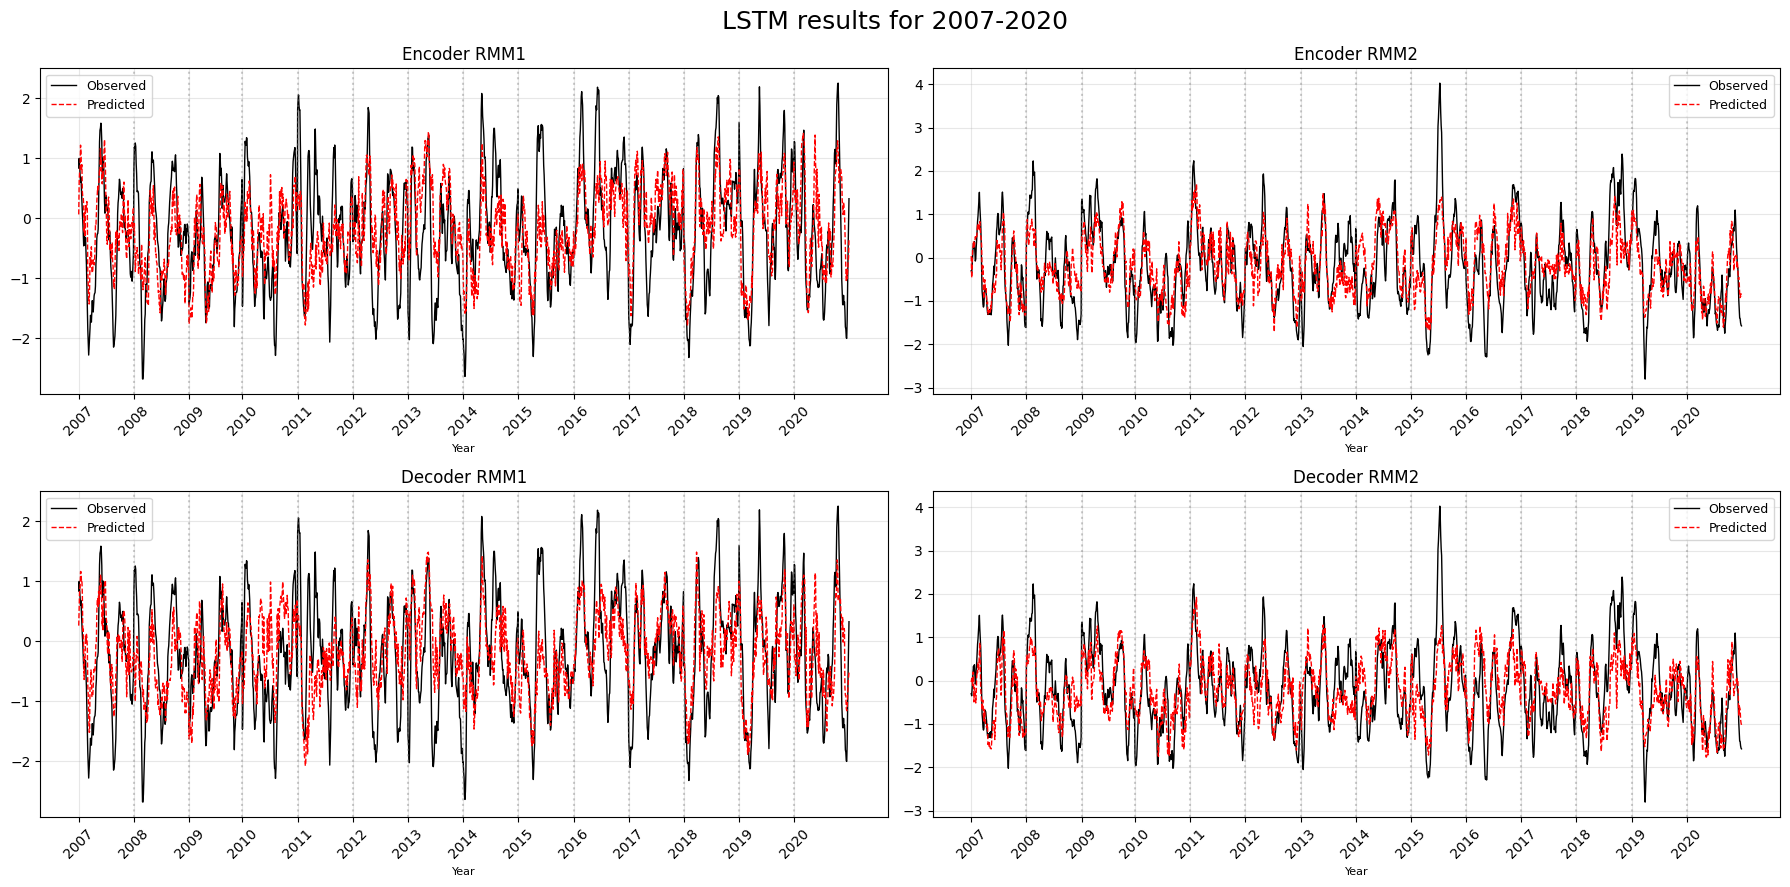

In [113]:
encode_rmm1_results = sorted(encode_rmm1_results, key=lambda r: r["test_year"])
encode_rmm2_results = sorted(encode_rmm2_results, key=lambda r: r["test_year"])
decode_rmm1_results = sorted(decode_rmm1_results, key=lambda r: r["test_year"])
decode_rmm2_results = sorted(decode_rmm2_results, key=lambda r: r["test_year"])

y_true_rmm1 = np.concatenate([r["true"] for r in encode_rmm1_results], axis=0).squeeze()
y_true_rmm2 = np.concatenate([r["true"] for r in encode_rmm2_results], axis=0).squeeze()

pred_e_rmm1 = np.concatenate([r["pred"] for r in encode_rmm1_results], axis=0).squeeze()
pred_e_rmm2 = np.concatenate([r["pred"] for r in encode_rmm2_results], axis=0).squeeze()

pred_d_rmm1 = np.concatenate([r["pred"] for r in decode_rmm1_results], axis=0).squeeze()
pred_d_rmm2 = np.concatenate([r["pred"] for r in decode_rmm2_results], axis=0).squeeze()

plot_year_labels_rmm1 = np.concatenate([
    np.full(len(r["true"]), r["test_year"]) for r in encode_rmm1_results
])

plot_year_labels_rmm2 = np.concatenate([
    np.full(len(r["true"]), r["test_year"]) for r in encode_rmm2_results
])

fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex=False)

panels = [
    ("Encoder", "RMM1", y_true_rmm1, pred_e_rmm1, plot_year_labels_rmm1),
    ("Encoder", "RMM2", y_true_rmm2, pred_e_rmm2, plot_year_labels_rmm2),
    ("Decoder", "RMM1", y_true_rmm1, pred_d_rmm1, plot_year_labels_rmm1),
    ("Decoder", "RMM2", y_true_rmm2, pred_d_rmm2, plot_year_labels_rmm2),
]

for ax, (model_name, target_name, obs, pred, year_labels_plot) in zip(axes.flat, panels):
    x = np.arange(len(obs))

    ax.plot(x, obs, "k-", lw=1, label="Observed")
    ax.plot(x, pred, "r--", lw=1, label="Predicted")

    year_positions = []
    year_names = []

    for i in range(len(year_labels_plot)):
        if i == 0 or year_labels_plot[i] != year_labels_plot[i - 1]:
            year_positions.append(i)
            year_names.append(str(year_labels_plot[i]))

            if i != 0:
                ax.axvline(x=i, color="gray", alpha=0.4, linestyle=":")

    ax.set_xticks(year_positions)
    ax.set_xticklabels(year_names, rotation=45)

    ax.set_title(f"{model_name} {target_name}")
    ax.set_xlabel("Year", fontsize=8)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("LSTM results for 2007-2020", fontsize=18)
plt.tight_layout()
plt.show()

### LSTM predict RMM1 & RMM2 together

In [155]:
seq_len = 7
y_rmm12_use = np.column_stack([y_rmm1_use, y_rmm2_use])

X_e_seq_rmm12, y_seq_rmm12, seq_years_rmm12 = make_sequences(
    X_e_rmm, y_rmm12_use, years_rmm, seq_len
)

X_d_seq_rmm12, _, _ = make_sequences(
    X_d_rmm, y_rmm12_use, years_rmm, seq_len
)

print("RMM1&RMM2 encoder:", X_e_seq_rmm12.shape, y_seq_rmm12.shape, seq_years_rmm12.shape)
print("RMM1&RMM2 decoder:", X_d_seq_rmm12.shape)

RMM1&RMM2 encoder: (1620, 7, 2560) (1620, 2) (1620,)
RMM1&RMM2 decoder: (1620, 7, 2560)


In [156]:
def run_one_fold_multivariate(test_year, X_seq, y_seq, seq_years, output_dim=2):
    train_mask = seq_years != test_year
    test_mask = seq_years == test_year

    X_train = X_seq[train_mask]
    X_test = X_seq[test_mask]
    y_train = y_seq[train_mask]
    y_test = y_seq[test_mask]

    X_train, X_test = standardize_sequences(X_train, X_test)

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.float32)
        ),
        batch_size=30,
        shuffle=True
    )

    test_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_test, dtype=torch.float32),
            torch.tensor(y_test, dtype=torch.float32)
        ),
        batch_size=30,
        shuffle=False
    )

    model = LSTM(
        latent_dim=X_seq.shape[-1],
        hidden_dim=128,
        num_layers=2,
        output_dim=output_dim,
    ).to(device)

    train_model(model, train_loader, epochs=25, lr=1e-4)

    pred, true = get_predictions(model, test_loader)

    mse_total = mean_squared_error(true, pred)
    r2_total = r2_score(true, pred, multioutput="uniform_average")

    return {
        "test_year": test_year,
        "pred": pred,
        "true": true,
        "mse": mse_total,
        "r2": r2_total
    }

In [157]:
encode_rmm12_results = []
decode_rmm12_results = []

for test_year in test_years:
    encode_rmm12_results.append(
        run_one_fold_multivariate(
            test_year, X_e_seq_rmm12, y_seq_rmm12, seq_years_rmm12, output_dim=2
        )
    )
    decode_rmm12_results.append(
        run_one_fold_multivariate(
            test_year, X_d_seq_rmm12, y_seq_rmm12, seq_years_rmm12, output_dim=2
        )
    )

def bivariate_correlation(y_true, y_pred):
    # columns = [RMM1, RMM2]
    numerator = np.sum(y_true[:, 0] * y_pred[:, 0] + y_true[:, 1] * y_pred[:, 1])
    denominator = np.sqrt(np.sum(y_true[:, 0]**2 + y_true[:, 1]**2)*np.sum(y_pred[:, 0]**2 + y_pred[:, 1]**2))
    return numerator / denominator


def print_results_multivariate(name, results):
    results = sorted(results, key=lambda r: r["test_year"])

    avg_mse = np.mean([r["mse"] for r in results])
    avg_r2 = np.mean([r["r2"] for r in results])

    all_pred = np.concatenate([r["pred"] for r in results], axis=0)
    all_true = np.concatenate([r["true"] for r in results], axis=0)

    bivariate_corr = bivariate_correlation(all_true, all_pred)

    print(name)
    for r in results:
        print(f'  year={r["test_year"]}, mse={r["mse"]:.4f}, r2={r["r2"]:.4f}')
    print(f'Average MSE: {avg_mse:.4f}')
    print(f'Average R^2: {avg_r2:.4f}')
    print(f'Bivariate Correlation: {bivariate_corr:.4f}')
    print()


print_results_multivariate("Encoder MJO", encode_rmm12_results)
print_results_multivariate("Decoder MJO", decode_rmm12_results)

Encoder MJO
  year=2007, mse=0.5000, r2=0.3854
  year=2008, mse=0.4711, r2=0.4461
  year=2009, mse=0.3858, r2=0.2931
  year=2010, mse=0.6083, r2=0.0154
  year=2011, mse=0.6501, r2=-0.0176
  year=2012, mse=0.4693, r2=0.3874
  year=2013, mse=0.4523, r2=0.2032
  year=2014, mse=0.6399, r2=0.1201
  year=2015, mse=1.0360, r2=0.1263
  year=2016, mse=1.0522, r2=-0.1681
  year=2017, mse=0.5379, r2=-0.2044
  year=2018, mse=0.7412, r2=0.3548
  year=2019, mse=0.4644, r2=0.4797
  year=2020, mse=0.7203, r2=0.1782
Average MSE: 0.6235
Average R^2: 0.1857
Bivariate Correlation: 0.5701

Decoder MJO
  year=2007, mse=0.4871, r2=0.4024
  year=2008, mse=0.6250, r2=0.2553
  year=2009, mse=0.3789, r2=0.3112
  year=2010, mse=0.8649, r2=-0.3776
  year=2011, mse=0.6295, r2=0.0146
  year=2012, mse=0.4054, r2=0.4708
  year=2013, mse=0.3831, r2=0.3255
  year=2014, mse=0.6261, r2=0.1377
  year=2015, mse=1.0053, r2=0.2047
  year=2016, mse=0.9993, r2=-0.1047
  year=2017, mse=0.5879, r2=-0.3109
  year=2018, mse=0.8890,

### Linear Regression for predicting MJO (7 day running mean)

In [164]:
def seasonal_rolling_mean_by_year(X, y1, y2, dates, window=7):
    df_X = pd.DataFrame(X, index=pd.to_datetime(dates))
    s_y1 = pd.Series(y1, index=pd.to_datetime(dates))
    s_y2 = pd.Series(y2, index=pd.to_datetime(dates))

    X_roll_list = []
    y1_roll_list = []
    y2_roll_list = []
    date_list = []
    year_list = []

    for yr in sorted(df_X.index.year.unique()):
        X_year = df_X[df_X.index.year == yr]
        y1_year = s_y1[s_y1.index.year == yr]
        y2_year = s_y2[s_y2.index.year == yr]

        X_year_roll = X_year.rolling(window=window, min_periods=window).mean()
        y1_year_roll = y1_year.rolling(window=window, min_periods=window).mean()
        y2_year_roll = y2_year.rolling(window=window, min_periods=window).mean()

        valid_mask = (
            np.isfinite(y1_year_roll.to_numpy()) &
            np.isfinite(y2_year_roll.to_numpy())
        )

        X_roll_list.append(X_year_roll.to_numpy()[valid_mask])
        y1_roll_list.append(y1_year_roll.to_numpy()[valid_mask])
        y2_roll_list.append(y2_year_roll.to_numpy()[valid_mask])
        date_list.append(X_year_roll.index[valid_mask])
        year_list.append(np.full(valid_mask.sum(), yr))

    X_roll = np.concatenate(X_roll_list, axis=0)
    y1_roll = np.concatenate(y1_roll_list, axis=0)
    y2_roll = np.concatenate(y2_roll_list, axis=0)
    out_dates = pd.DatetimeIndex(np.concatenate(date_list))
    out_years = np.concatenate(year_list)

    return X_roll, y1_roll, y2_roll, out_dates, out_years

In [159]:
year_use = (2007,2008,2009,2010,2011,2012,2013,2014, 2015, 2016, 2017, 2018, 2019, 2020)

year_mask_rmm = np.isin(year_labels, year_use)

X_e_rmm = latent_array_e[year_mask_rmm]
X_d_rmm = latent_array_d[year_mask_rmm]
y_rmm1_use = y_rmm1[year_mask_rmm]
y_rmm2_use = y_rmm2[year_mask_rmm]
dates_rmm = latent_times[year_mask_rmm]

X_e_roll, y_rmm1_roll, y_rmm2_roll, roll_dates, years_roll = seasonal_rolling_mean_by_year(
    X_e_rmm, y_rmm1_use, y_rmm2_use, dates_rmm, window=7
)

X_d_roll, _, _, _, _ = seasonal_rolling_mean_by_year(
    X_d_rmm, y_rmm1_use, y_rmm2_use, dates_rmm, window=7
)

y_rmm12_roll = np.column_stack([y_rmm1_roll, y_rmm2_roll])

print("Encoder rolling latent:", X_e_roll.shape)
print("Decoder rolling latent:", X_d_roll.shape)
print("Rolling target:", y_rmm12_roll.shape)
print("Years:", np.unique(years_roll))

Encoder rolling latent: (1634, 2560)
Decoder rolling latent: (1634, 2560)
Rolling target: (1634, 2)
Years: [2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]


In [166]:
def run_one_fold_ridge_multivariate(test_year, X, y, years, alpha=1, n_components=20):
    train_mask = years != test_year
    test_mask = years == test_year

    X_train = X[train_mask]
    y_train = y[train_mask]
    X_test = X[test_mask]
    y_test = y[test_mask]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mse_total = mean_squared_error(y_test, pred)
    r2_total = r2_score(y_test, pred, multioutput="uniform_average")

    return {
        "test_year": test_year,
        "pred": pred,
        "true": y_test,
        "mse": mse_total,
        "r2": r2_total
    }

def print_results_multivariate(name, results):
    results = sorted(results, key=lambda r: r["test_year"])

    avg_mse = np.mean([r["mse"] for r in results])
    avg_r2 = np.mean([r["r2"] for r in results])

    all_pred = np.concatenate([r["pred"] for r in results], axis=0)
    all_true = np.concatenate([r["true"] for r in results], axis=0)

    bivariate_corr = bivariate_correlation(all_true, all_pred)

    print(name)
    for r in results:
        print(f'  year={r["test_year"]}, mse={r["mse"]:.4f}, r2={r["r2"]:.4f}')
    print(f'Average MSE: {avg_mse:.4f}')
    print(f'Average R^2: {avg_r2:.4f}')
    print(f'Bivariate Correlation: {bivariate_corr:.4f}')
    print()

In [167]:
ridge_encode_rmm12_roll_results = []
ridge_decode_rmm12_roll_results = []

for test_year in test_years:
    ridge_encode_rmm12_roll_results.append(
        run_one_fold_ridge_multivariate(
            test_year,
            X_e_roll,
            y_rmm12_roll,
            years_roll,
            alpha=1.0,
            n_components=20
        )
    )

    ridge_decode_rmm12_roll_results.append(
        run_one_fold_ridge_multivariate(
            test_year,
            X_d_roll,
            y_rmm12_roll,
            years_roll,
            alpha=1.0,
            n_components=20
        )
    )

print_results_multivariate("Ridge Encoder MJO (7-day running mean)", ridge_encode_rmm12_roll_results)
print_results_multivariate("Ridge Decoder MJO (7-day running mean)", ridge_decode_rmm12_roll_results)

Ridge Encoder MJO (7-day running mean)
  year=2007, mse=0.6141, r2=0.0436
  year=2008, mse=0.5148, r2=0.3367
  year=2009, mse=0.2349, r2=0.5546
  year=2010, mse=0.4028, r2=0.1842
  year=2011, mse=0.3457, r2=0.3662
  year=2012, mse=0.3702, r2=0.4136
  year=2013, mse=0.4459, r2=0.1011
  year=2014, mse=0.3203, r2=0.5444
  year=2015, mse=0.4937, r2=0.4705
  year=2016, mse=0.5740, r2=0.2795
  year=2017, mse=0.2950, r2=0.1689
  year=2018, mse=0.5665, r2=0.4701
  year=2019, mse=0.3599, r2=0.5358
  year=2020, mse=0.3963, r2=0.3130
Average MSE: 0.4239
Average R^2: 0.3416
Bivariate Correlation: 0.6930

Ridge Decoder MJO (7-day running mean)
  year=2007, mse=0.5615, r2=0.1363
  year=2008, mse=0.4010, r2=0.4846
  year=2009, mse=0.2386, r2=0.5414
  year=2010, mse=0.4164, r2=0.1709
  year=2011, mse=0.3496, r2=0.3589
  year=2012, mse=0.3476, r2=0.4486
  year=2013, mse=0.4829, r2=0.0406
  year=2014, mse=0.3551, r2=0.4903
  year=2015, mse=0.5216, r2=0.4447
  year=2016, mse=0.5854, r2=0.3020
  year=2017

### LSTM for IOD

In [168]:
# Align latent data with IOD by date
iod_target = iod_df.copy()
iod_target["time"] = pd.to_datetime(iod_target["time"])
iod_target = iod_target.set_index("time")
iod_target = iod_target.reindex(daily_index)
iod_target = iod_target.loc[latent_dates][["anom"]]

y_iod = iod_target["anom"].values
print(iod_target.head())
print(y_iod.shape)

            anom
1980-05-01   NaN
1980-05-02   NaN
1980-05-03   NaN
1980-05-04   NaN
1980-05-05   NaN
(2267,)


In [176]:
# sequence preprocessing
year_use = (2007,2008,2009,2010,2011,2012,2013,2014, 2015, 2016, 2017, 2018, 2019, 2020)
seq_len = 21

# reuse existing make_sequences function if it is already defined above
iod_mask = np.isin(year_labels, year_use) & np.isfinite(y_iod.squeeze())

years_iod = year_labels[iod_mask]
X_e_iod = latent_array_e[iod_mask]
X_d_iod = latent_array_d[iod_mask]
y_iod_use = y_iod[iod_mask]

X_e_seq_iod, y_seq_iod, seq_years_iod = make_sequences(
    X_e_iod, y_iod_use, years_iod, seq_len
)
X_d_seq_iod, _, _ = make_sequences(
    X_d_iod, y_iod_use, years_iod, seq_len
)

print("IOD encoder:", X_e_seq_iod.shape, y_seq_iod.shape, seq_years_iod.shape)
print("IOD decoder:", X_d_seq_iod.shape)

IOD encoder: (1424, 21, 2560) (1424,) (1424,)
IOD decoder: (1424, 21, 2560)


In [177]:
test_years = [2007,2008,2009,2010,2011,2012,2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
encode_iod_results = []
decode_iod_results = []

for test_year in test_years:
    encode_iod_results.append(
        run_one_fold(test_year, X_e_seq_iod, y_seq_iod, seq_years_iod, output_dim=1)
    )
    decode_iod_results.append(
        run_one_fold(test_year, X_d_seq_iod, y_seq_iod, seq_years_iod, output_dim=1)
    )

In [178]:
print_results("Encoder IOD", encode_iod_results)
print_results("Decoder IOD", decode_iod_results)

Encoder IOD
  year=2007, mse=0.1251, r2=-0.5739
  year=2008, mse=0.5452, r2=-0.7098
  year=2009, mse=0.3313, r2=-1.9342
  year=2010, mse=0.0727, r2=0.1642
  year=2011, mse=0.0905, r2=0.1491
  year=2012, mse=0.6489, r2=-1.4660
  year=2013, mse=0.0795, r2=0.3049
  year=2014, mse=0.3338, r2=-0.3851
  year=2015, mse=0.2154, r2=0.1228
  year=2016, mse=0.8770, r2=-5.7055
  year=2017, mse=0.0495, r2=0.3055
  year=2018, mse=0.2736, r2=-3.6039
  year=2019, mse=0.4826, r2=-2.8560
  year=2020, mse=0.2578, r2=-0.0494
Average MSE: 0.3131
Average R^2: -1.1598
Correlation: 0.3559

Decoder IOD
  year=2007, mse=0.1441, r2=-0.8133
  year=2008, mse=0.6243, r2=-0.9578
  year=2009, mse=0.3289, r2=-1.9130
  year=2010, mse=0.0940, r2=-0.0806
  year=2011, mse=0.1038, r2=0.0246
  year=2012, mse=0.6667, r2=-1.5340
  year=2013, mse=0.0944, r2=0.1743
  year=2014, mse=0.2847, r2=-0.1815
  year=2015, mse=0.1678, r2=0.3166
  year=2016, mse=0.9127, r2=-5.9785
  year=2017, mse=0.1257, r2=-0.7634
  year=2018, mse=0.294

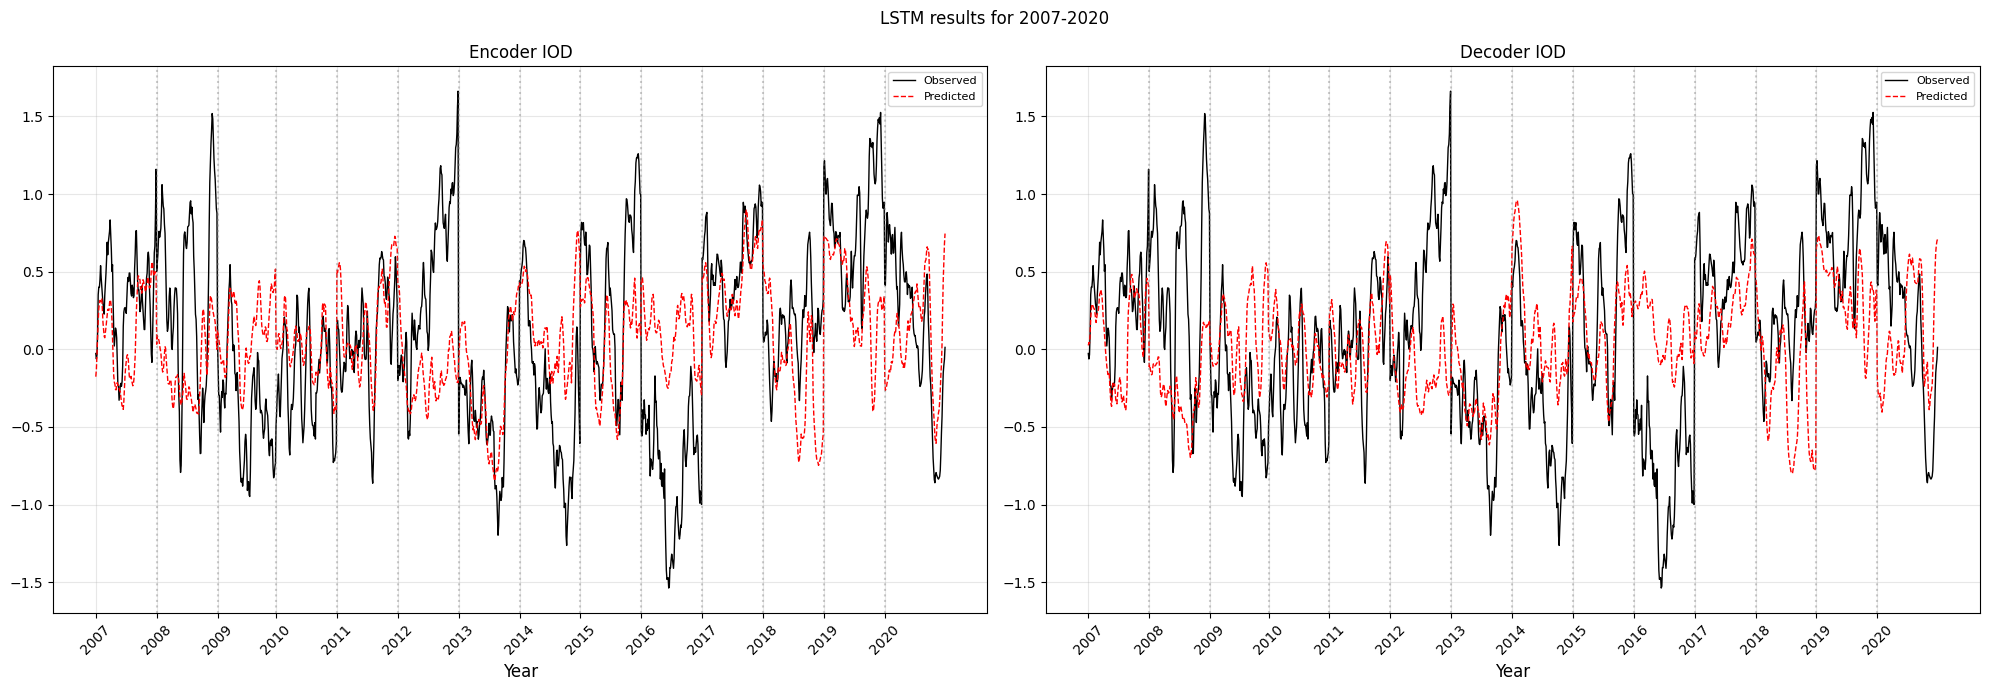

In [187]:
encode_iod_results = sorted(encode_iod_results, key=lambda r: r["test_year"])
decode_iod_results = sorted(decode_iod_results, key=lambda r: r["test_year"])

y_true_iod = np.concatenate([r["true"] for r in encode_iod_results], axis=0)
pred_e_iod = np.concatenate([r["pred"] for r in encode_iod_results], axis=0)
pred_d_iod = np.concatenate([r["pred"] for r in decode_iod_results], axis=0)
plot_year_labels_iod = np.concatenate([
    np.full(len(r["true"]), r["test_year"]) for r in encode_iod_results
])

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharex=False)

panels = [
    ("Encoder", "IOD", y_true_iod, pred_e_iod, plot_year_labels_iod),
    ("Decoder", "IOD", y_true_iod, pred_d_iod, plot_year_labels_iod),
]

for ax, (model_name, target_name, obs, pred, year_labels_plot) in zip(axes.flat, panels):
    x = np.arange(len(obs))

    ax.plot(x, obs, "k-", lw=1, label="Observed")
    ax.plot(x, pred, "r--", lw=1, label="Predicted")

    year_positions = []
    year_names = []

    for i in range(len(year_labels_plot)):
        if i == 0 or year_labels_plot[i] != year_labels_plot[i - 1]:
            year_positions.append(i)
            year_names.append(str(year_labels_plot[i]))

            if i != 0:
                ax.axvline(x=i, color="gray", alpha=0.4, linestyle=":")

    ax.set_xticks(year_positions)
    ax.set_xticklabels(year_names, rotation=45)

    ax.set_title(f"{model_name} {target_name}")
    ax.set_xlabel("Year",fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("LSTM results for 2007-2020")
plt.tight_layout()
plt.show()

### LSTM for Nino34

In [180]:
# sequence preprocessing
year_use = (2007,2008,2009,2010,2011,2012,2013,2014, 2015, 2016, 2017, 2018, 2019, 2020)
seq_len = 21
def make_sequences(X, y, years, seq_len):
    X_seq, y_seq, seq_years = [], [], []
    for yr in np.unique(years):
        idx = np.where(years == yr)[0]
        X_year = X[idx]
        y_year = y[idx]
        for i in range(len(X_year) - seq_len):
            X_seq.append(X_year[i:i+seq_len])
            y_seq.append(y_year[i+seq_len])
            seq_years.append(yr)
    return np.array(X_seq), np.array(y_seq), np.array(seq_years)
nino_mask = np.isin(year_labels, year_use) & np.isfinite(y_nino.squeeze())

years_nino = year_labels[nino_mask]
X_e_nino = latent_array_e[nino_mask]
X_d_nino = latent_array_d[nino_mask]
y_nino_use = y_nino[nino_mask]

X_e_seq_nino, y_seq_nino, seq_years_nino = make_sequences(
    X_e_nino, y_nino_use, years_nino, seq_len
)
X_d_seq_nino, _, _ = make_sequences(
    X_d_nino, y_nino_use, years_nino, seq_len
)

print("Nino encoder:", X_e_seq_nino.shape, y_seq_nino.shape, seq_years_nino.shape)
print("Nino decoder:", X_d_seq_nino.shape)

Nino encoder: (1424, 21, 2560) (1424,) (1424,)
Nino decoder: (1424, 21, 2560)


In [181]:
test_years = [2007,2008,2009,2010,2011,2012,2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
encode_nino_results = []
decode_nino_results = []

for test_year in test_years:
    encode_nino_results.append(
        run_one_fold(test_year, X_e_seq_nino, y_seq_nino, seq_years_nino, output_dim=1)
    )
    decode_nino_results.append(
        run_one_fold(test_year, X_d_seq_nino, y_seq_nino, seq_years_nino, output_dim=1)
    )

In [182]:
def print_results(name, results):
    results = sorted(results, key=lambda r: r["test_year"])
    avg_mse = np.mean([r["mse"] for r in results])
    avg_r2 = np.mean([r["r2"] for r in results])
    all_pred = np.concatenate([r["pred"].squeeze(-1) for r in results])
    all_true = np.concatenate([r["true"].squeeze(-1) for r in results])
    corr = np.corrcoef(all_true, all_pred)[0, 1]

    print(name)
    for r in results:
        print(f'  year={r["test_year"]}, mse={r["mse"]:.4f}, r2={r["r2"]:.4f}')
    print(f'Average MSE: {avg_mse:.4f}')
    print(f'Average R^2: {avg_r2:.4f}')
    print(f'Correlation: {corr:.4f}')
    print()

print_results("Encoder Nino3.4", encode_nino_results)
print_results("Decoder Nino3.4", decode_nino_results)

Encoder Nino3.4
  year=2007, mse=0.2387, r2=-2.5847
  year=2008, mse=0.0977, r2=-0.7950
  year=2009, mse=0.3484, r2=-12.2179
  year=2010, mse=0.5623, r2=-2.1090
  year=2011, mse=0.1623, r2=-3.3027
  year=2012, mse=0.6287, r2=-4.2385
  year=2013, mse=0.0679, r2=-0.4819
  year=2014, mse=0.2738, r2=-1.2580
  year=2015, mse=1.6468, r2=-19.8078
  year=2016, mse=0.2296, r2=-1.3761
  year=2017, mse=0.0581, r2=0.2073
  year=2018, mse=0.2727, r2=-12.9458
  year=2019, mse=0.0354, r2=0.5978
  year=2020, mse=0.1272, r2=-1.2075
Average MSE: 0.3393
Average R^2: -4.3943
Correlation: 0.3184

Decoder Nino3.4
  year=2007, mse=0.2410, r2=-2.6185
  year=2008, mse=0.1368, r2=-1.5149
  year=2009, mse=0.2974, r2=-10.2824
  year=2010, mse=0.7836, r2=-3.3322
  year=2011, mse=0.2344, r2=-5.2147
  year=2012, mse=0.6492, r2=-4.4099
  year=2013, mse=0.0763, r2=-0.6666
  year=2014, mse=0.1772, r2=-0.4616
  year=2015, mse=1.7333, r2=-20.8998
  year=2016, mse=0.2570, r2=-1.6591
  year=2017, mse=0.0360, r2=0.5088
  ye

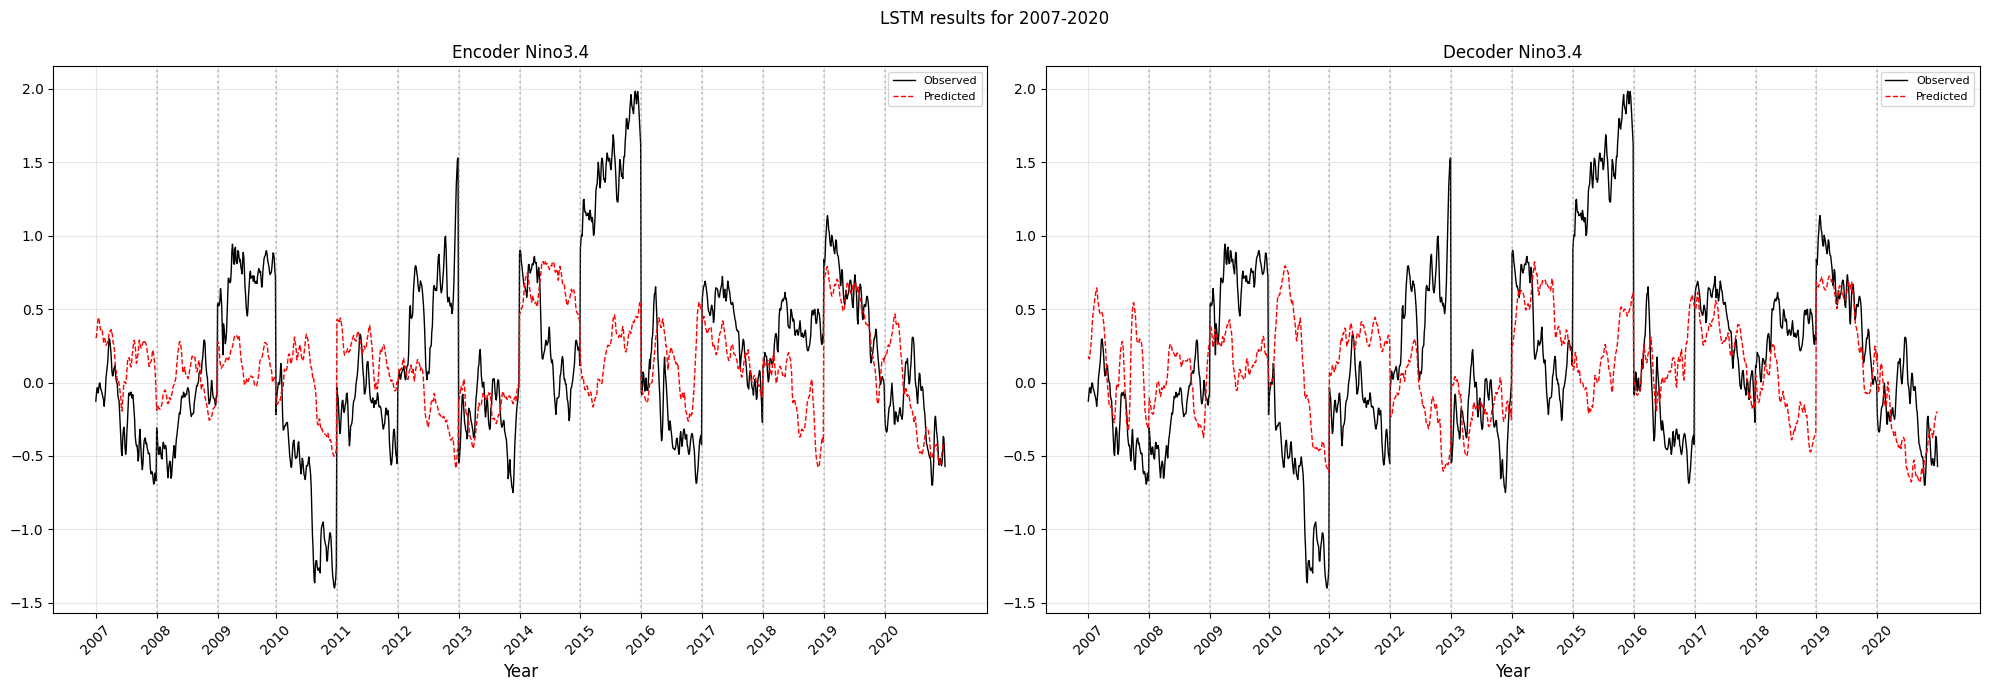

In [188]:
encode_nino_results = sorted(encode_nino_results, key=lambda r: r["test_year"])
decode_nino_results = sorted(decode_nino_results, key=lambda r: r["test_year"])

y_true_nino = np.concatenate([r["true"] for r in encode_nino_results], axis=0).squeeze()
pred_e_nino = np.concatenate([r["pred"] for r in encode_nino_results], axis=0).squeeze()
pred_d_nino = np.concatenate([r["pred"] for r in decode_nino_results], axis=0).squeeze()

plot_year_labels_nino = np.concatenate([
    np.full(len(r["true"]), r["test_year"]) for r in encode_nino_results
])

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharex=False)

panels = [
    ("Encoder", "Nino3.4", y_true_nino, pred_e_nino, plot_year_labels_nino),
    ("Decoder", "Nino3.4", y_true_nino, pred_d_nino, plot_year_labels_nino),
]

for ax, (model_name, target_name, obs, pred, year_labels_plot) in zip(axes.flat, panels):
    x = np.arange(len(obs))

    ax.plot(x, obs, "k-", lw=1, label="Observed")
    ax.plot(x, pred, "r--", lw=1, label="Predicted")

    year_positions = []
    year_names = []

    for i in range(len(year_labels_plot)):
        if i == 0 or year_labels_plot[i] != year_labels_plot[i - 1]:
            year_positions.append(i)
            year_names.append(str(year_labels_plot[i]))

            if i != 0:
                ax.axvline(x=i, color="gray", alpha=0.4, linestyle=":")

    ax.set_xticks(year_positions)
    ax.set_xticklabels(year_names, rotation=45)

    ax.set_title(f"{model_name} {target_name}")
    ax.set_xlabel("Year", fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("LSTM results for 2007-2020")
fig.subplots_adjust(wspace=0.08, top=0.86)
plt.tight_layout()
plt.show()

### Linear Regression

In [48]:
year_use = (2010,2011,2012,2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020)
year_mask_nino = np.isin(year_labels, year_use) & np.isfinite(y_nino)
years_nino = year_labels[year_mask_nino]
X_e_nino_direct = latent_array_e[year_mask_nino]
X_d_nino_direct = latent_array_d[year_mask_nino]
y_nino_direct = y_nino[year_mask_nino]

print("Encoder Nino direct:", X_e_nino_direct.shape, y_nino_direct.shape)
print("Decoder Nino direct:", X_d_nino_direct.shape, y_nino_direct.shape)

Encoder Nino direct: (1353, 2560) (1353,)
Decoder Nino direct: (1353, 2560) (1353,)


In [49]:
def run_one_fold_ridge(test_year, X, y, years, alpha=1.0, n_components=50):
    train_mask = years != test_year
    test_mask = years == test_year

    X_train = X[train_mask]
    y_train = y[train_mask]
    X_test = X[test_mask]
    y_test = y[test_mask]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mse_total = mean_squared_error(y_test, pred)
    r2_total = r2_score(y_test, pred)

    return {
        "test_year": test_year,
        "pred": pred,
        "true": y_test,
        "mse": mse_total,
        "r2": r2_total
    }

In [50]:
test_years = [2010,2011,2012,2013,2014, 2015, 2016, 2017, 2018, 2019, 2020]

ridge_encode_nino_results = []
ridge_decode_nino_results = []

for test_year in test_years:
    ridge_encode_nino_results.append(
        run_one_fold_ridge(
            test_year,
            X_e_nino_direct,
            y_nino_direct,
            years_nino,
            alpha=0.5,
            n_components=3
        )
    )

    ridge_decode_nino_results.append(
        run_one_fold_ridge(
            test_year,
            X_d_nino_direct,
            y_nino_direct,
            years_nino,
            alpha=0.5,
            n_components=3
        )
    )

In [51]:
def print_results(name, results):
    results = sorted(results, key=lambda r: r["test_year"])
    avg_mse = np.mean([r["mse"] for r in results])
    avg_r2 = np.mean([r["r2"] for r in results])
    all_pred = np.concatenate([np.asarray(r["pred"]).reshape(-1) for r in results])
    all_true = np.concatenate([np.asarray(r["true"]).reshape(-1) for r in results])
    corr = np.corrcoef(all_true, all_pred)[0, 1]


    print(name)
    for r in results:
        print(f'  year={r["test_year"]}, mse={r["mse"]:.4f}, r2={r["r2"]:.4f}')
    print(f'Average MSE: {avg_mse:.4f}')
    print(f'Average R^2: {avg_r2:.4f}')
    print(f'Correlation: {corr:.4f}')
    print()

In [52]:
print_results("Ridge Encoder Nino3.4", ridge_encode_nino_results)
print_results("Ridge Decoder Nino3.4", ridge_decode_nino_results)

Ridge Encoder Nino3.4
  year=2010, mse=0.8346, r2=-2.6522
  year=2011, mse=0.3765, r2=-6.5312
  year=2012, mse=0.3920, r2=-1.4507
  year=2013, mse=0.1946, r2=-2.9991
  year=2014, mse=0.0728, r2=0.3263
  year=2015, mse=1.8533, r2=-15.7249
  year=2016, mse=0.1513, r2=0.0826
  year=2017, mse=0.0469, r2=0.2621
  year=2018, mse=0.1550, r2=-2.6028
  year=2019, mse=0.1816, r2=-1.1678
  year=2020, mse=0.2645, r2=-3.5712
Average MSE: 0.4112
Average R^2: -3.2754
Correlation: -0.0360

Ridge Decoder Nino3.4
  year=2010, mse=0.9121, r2=-2.9911
  year=2011, mse=0.4115, r2=-7.2303
  year=2012, mse=0.3688, r2=-1.3054
  year=2013, mse=0.2246, r2=-3.6165
  year=2014, mse=0.0999, r2=0.0746
  year=2015, mse=1.9095, r2=-16.2322
  year=2016, mse=0.1663, r2=-0.0082
  year=2017, mse=0.0448, r2=0.2952
  year=2018, mse=0.1568, r2=-2.6457
  year=2019, mse=0.1879, r2=-1.2433
  year=2020, mse=0.1931, r2=-2.3374
Average MSE: 0.4250
Average R^2: -3.3855
Correlation: -0.0742



### 7 day running mean (overlapping, slide window, keep same number of samples)

In [53]:
latent_dates = latent_times.normalize()

latent_e_7d_roll = (
    pd.DataFrame(latent_array_e, index=latent_dates)
    .rolling(window=7, min_periods=7)
    .mean()
    .to_numpy()
)

latent_d_7d_roll = (
    pd.DataFrame(latent_array_d, index=latent_dates)
    .rolling(window=7, min_periods=7)
    .mean()
    .to_numpy()
)

y_rmm1_7d_roll = (
    pd.Series(y_rmm1, index=latent_dates)
    .rolling(window=7, min_periods=7)
    .mean()
    .to_numpy()
)

y_rmm2_7d_roll = (
    pd.Series(y_rmm2, index=latent_dates)
    .rolling(window=7, min_periods=7)
    .mean()
    .to_numpy()
)

y_nino_7d_roll = (
    pd.Series(y_nino, index=latent_dates)
    .rolling(window=7, min_periods=7)
    .mean()
    .to_numpy()
)

print("latent_e_7d_roll:", latent_e_7d_roll.shape)
print("latent_d_7d_roll:", latent_d_7d_roll.shape)
print("y_rmm1_7d_roll:", y_rmm1_7d_roll.shape)
print("y_rmm2_7d_roll:", y_rmm2_7d_roll.shape)
print("y_nino_7d_roll:", y_nino_7d_roll.shape)

latent_e_7d_roll: (1902, 2560)
latent_d_7d_roll: (1902, 2560)
y_rmm1_7d_roll: (1902,)
y_rmm2_7d_roll: (1902,)
y_nino_7d_roll: (1902,)


In [54]:
valid_mask = (
    np.isfinite(y_nino_7d_roll) &
    np.isfinite(y_rmm1_7d_roll) &
    np.isfinite(y_rmm2_7d_roll)
)

X_e_roll = latent_e_7d_roll[valid_mask]
X_d_roll = latent_d_7d_roll[valid_mask]

y_rmm1_roll = y_rmm1_7d_roll[valid_mask]
y_rmm2_roll = y_rmm2_7d_roll[valid_mask]
y_nino_roll = y_nino_7d_roll[valid_mask]

years_roll = year_labels[valid_mask]

print(X_e_roll.shape, y_nino_roll.shape, years_roll.shape)

(1650, 2560) (1650,) (1650,)


In [57]:
year_use = np.arange(2010, 2021)

year_mask = np.isin(years_roll, year_use)

X_e_roll_use = X_e_roll[year_mask]
X_d_roll_use = X_d_roll[year_mask]

y_rmm1_roll_use = y_rmm1_roll[year_mask]
y_rmm2_roll_use = y_rmm2_roll[year_mask]
y_nino_roll_use = y_nino_roll[year_mask]

years_roll_use = years_roll[year_mask]

print(X_e_roll_use.shape, y_nino_roll_use.shape, years_roll_use.shape)
print(np.unique(years_roll_use))

(1353, 2560) (1353,) (1353,)
[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]


In [96]:
scaler_e = StandardScaler()
X_e_roll_std = scaler_e.fit_transform(X_e_roll_use)

pca_e = PCA(n_components=50)
X_e_roll_pca = pca_e.fit_transform(X_e_roll_std)

scaler_d = StandardScaler()
X_d_roll_std = scaler_d.fit_transform(X_d_roll_use)

pca_d = PCA(n_components=50)
X_d_roll_pca = pca_d.fit_transform(X_d_roll_std)

print("Encoder standardized shape:", X_e_roll_std.shape)
print("Encoder PCA scores shape:", X_e_roll_pca.shape)

print("Decoder standardized shape:", X_d_roll_std.shape)
print("Decoder PCA scores shape:", X_d_roll_pca.shape)

Encoder standardized shape: (1353, 2560)
Encoder PCA scores shape: (1353, 50)
Decoder standardized shape: (1353, 2560)
Decoder PCA scores shape: (1353, 50)


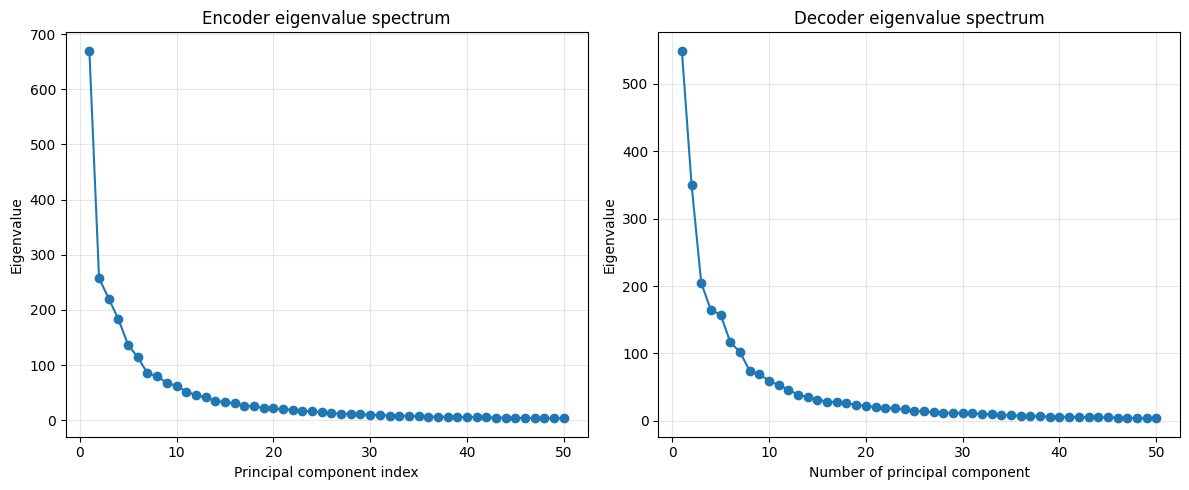

In [97]:
eigvals_e = pca_e.explained_variance_
eigvals_d = pca_d.explained_variance_
plt.figure(figsize=(12, 5))

# Encoder subplot
plt.subplot(1, 2, 1)
plt.plot(np.arange(1, len(eigvals_e) + 1), eigvals_e, marker='o')
plt.xlabel("Principal component index")
plt.ylabel("Eigenvalue")
plt.title("Encoder eigenvalue spectrum")
plt.grid(True, alpha=0.3)

# Decoder subplot
plt.subplot(1, 2, 2)
plt.plot(np.arange(1, len(eigvals_d) + 1), eigvals_d, marker='o')
plt.xlabel("Number of principal component")
plt.ylabel("Eigenvalue")
plt.title("Decoder eigenvalue spectrum")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Reconstruct RMM1/RMM2 using 25 PCAs

In [99]:
def run_one_fold_ridge(test_year, X, y, years, alpha=1.0):
    train_mask = years != test_year
    test_mask = years == test_year

    X_train = X[train_mask]
    y_train = y[train_mask]
    X_test = X[test_mask]
    y_test = y[test_mask]

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mse_total = mean_squared_error(y_test, pred)
    r2_total = r2_score(y_test, pred)

    return {
        "test_year": test_year,
        "pred": pred,
        "true": y_test,
        "mse": mse_total,
        "r2": r2_total,
    }

def print_results(name, results):
    results = sorted(results, key=lambda r: r["test_year"])
    avg_mse = np.mean([r["mse"] for r in results])
    avg_r2 = np.mean([r["r2"] for r in results])

    all_pred = np.concatenate([np.asarray(r["pred"]).reshape(-1) for r in results])
    all_true = np.concatenate([np.asarray(r["true"]).reshape(-1) for r in results])
    corr = np.corrcoef(all_true, all_pred)[0, 1]
    print(name)
    for r in results:
        print(f'  year={r["test_year"]}, mse={r["mse"]:.4f}, r2={r["r2"]:.4f}')
    print(f"Average MSE: {avg_mse:.4f}")
    print(f"Average R^2: {avg_r2:.4f}")
    print(f"Correlation: {corr:.4f}")
    print()


test_years = sorted(np.unique(years_roll_use))

ridge_e_rmm1_results = []
ridge_e_rmm2_results = []
ridge_d_rmm1_results = []
ridge_d_rmm2_results = []

for test_year in test_years:
    ridge_e_rmm1_results.append(
        run_one_fold_ridge(test_year, X_e_roll_pca, y_rmm1_roll_use, years_roll_use, alpha=1.0)
    )
    ridge_e_rmm2_results.append(
        run_one_fold_ridge(test_year, X_e_roll_pca, y_rmm2_roll_use, years_roll_use, alpha=1.0)
    )
    ridge_d_rmm1_results.append(
        run_one_fold_ridge(test_year, X_d_roll_pca, y_rmm1_roll_use, years_roll_use, alpha=1.0)
    )
    ridge_d_rmm2_results.append(
        run_one_fold_ridge(test_year, X_d_roll_pca, y_rmm2_roll_use, years_roll_use, alpha=1.0)
    )
print_results("Encoder 50PCs for RMM1", ridge_e_rmm1_results)
print_results("Encoder 50PCs for RMM2", ridge_e_rmm2_results)
print_results("Decoder 50PCs for RMM1", ridge_d_rmm1_results)
print_results("Decoder 50PCs for RMM2", ridge_d_rmm2_results)

Encoder 50PCs for RMM1
  year=2010, mse=0.4132, r2=0.2698
  year=2011, mse=2.2472, r2=-2.9032
  year=2012, mse=0.5277, r2=0.1170
  year=2013, mse=0.3707, r2=0.3490
  year=2014, mse=0.2970, r2=0.6650
  year=2015, mse=0.3667, r2=0.4263
  year=2016, mse=0.2332, r2=0.6187
  year=2017, mse=0.2689, r2=0.4525
  year=2018, mse=0.3884, r2=0.5806
  year=2019, mse=0.2753, r2=0.6888
  year=2020, mse=0.5695, r2=0.3169
Average MSE: 0.5416
Average R^2: 0.1438
Correlation: 0.6467

Encoder 50PCs for RMM2
  year=2010, mse=1.0777, r2=-1.4477
  year=2011, mse=0.8867, r2=-0.6973
  year=2012, mse=0.7583, r2=-0.2171
  year=2013, mse=0.4142, r2=-0.0514
  year=2014, mse=0.1594, r2=0.7220
  year=2015, mse=0.3239, r2=0.7833
  year=2016, mse=0.4858, r2=0.5151
  year=2017, mse=0.2506, r2=0.2706
  year=2018, mse=0.1893, r2=0.8319
  year=2019, mse=0.2298, r2=0.6653
  year=2020, mse=0.1454, r2=0.6894
Average MSE: 0.4474
Average R^2: 0.1876
Correlation: 0.7557

Decoder 50PCs for RMM1
  year=2010, mse=0.7705, r2=-0.361

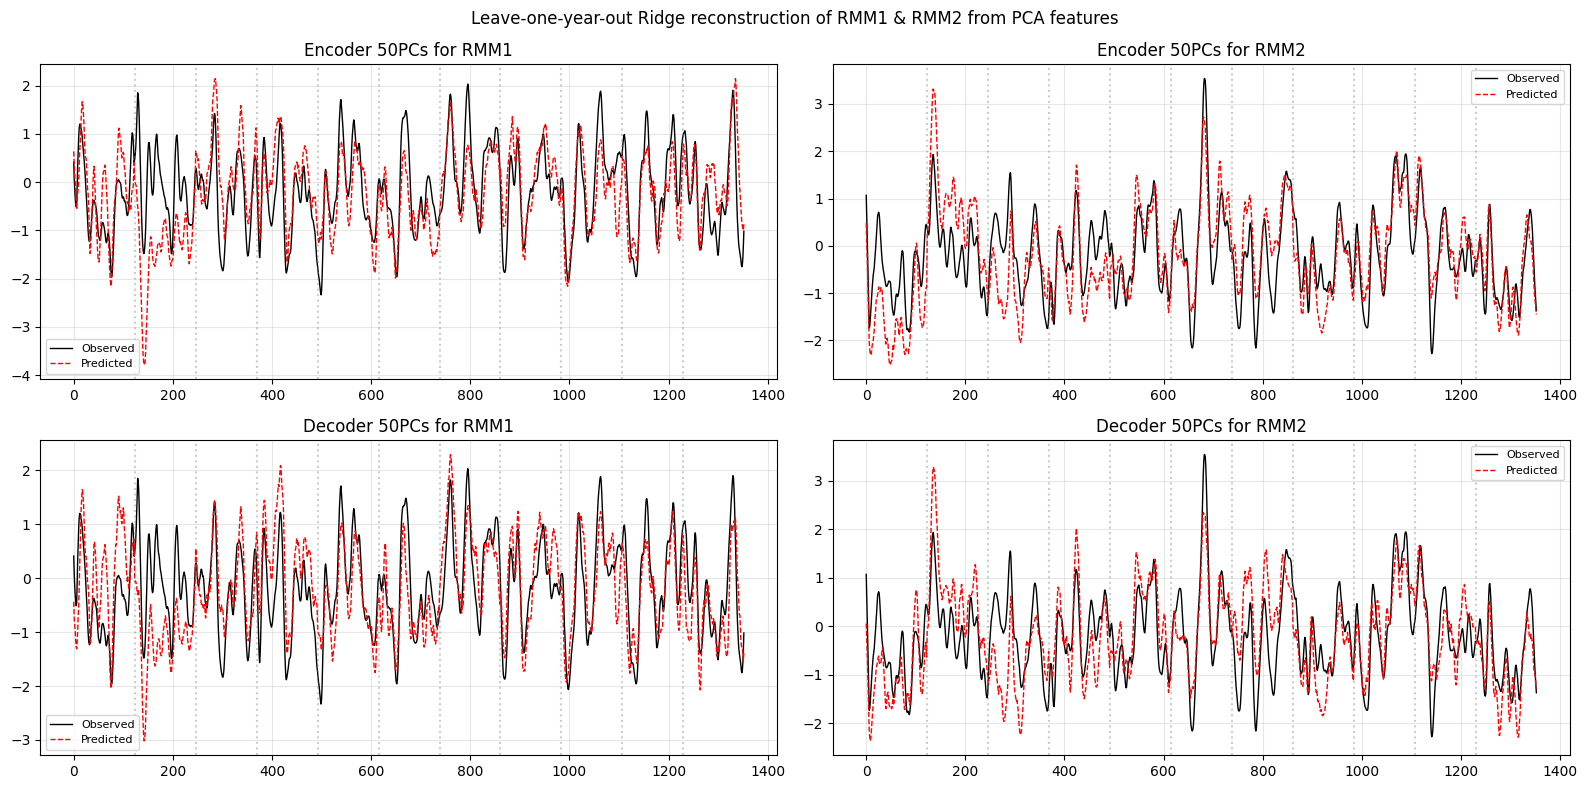

In [100]:
# Optional plots
ridge_e_rmm1_results = sorted(ridge_e_rmm1_results, key=lambda r: r["test_year"])
ridge_e_rmm2_results = sorted(ridge_e_rmm2_results, key=lambda r: r["test_year"])
ridge_d_rmm1_results = sorted(ridge_d_rmm1_results, key=lambda r: r["test_year"])
ridge_d_rmm2_results = sorted(ridge_d_rmm2_results, key=lambda r: r["test_year"])

y_true_rmm1 = np.concatenate([r["true"] for r in ridge_e_rmm1_results], axis=0).reshape(-1)
y_true_rmm2 = np.concatenate([r["true"] for r in ridge_e_rmm2_results], axis=0).reshape(-1)

pred_e_rmm1 = np.concatenate([r["pred"] for r in ridge_e_rmm1_results], axis=0).reshape(-1)
pred_e_rmm2 = np.concatenate([r["pred"] for r in ridge_e_rmm2_results], axis=0).reshape(-1)
pred_d_rmm1 = np.concatenate([r["pred"] for r in ridge_d_rmm1_results], axis=0).reshape(-1)
pred_d_rmm2 = np.concatenate([r["pred"] for r in ridge_d_rmm2_results], axis=0).reshape(-1)

plot_year_labels = np.concatenate([
    np.full(len(np.asarray(r["true"]).reshape(-1)), r["test_year"])
    for r in ridge_e_rmm1_results
])

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

panels = [
    ("Encoder", "RMM1", y_true_rmm1, pred_e_rmm1, plot_year_labels),
    ("Encoder", "RMM2", y_true_rmm2, pred_e_rmm2, plot_year_labels),
    ("Decoder", "RMM1", y_true_rmm1, pred_d_rmm1, plot_year_labels),
    ("Decoder", "RMM2", y_true_rmm2, pred_d_rmm2, plot_year_labels),
]

for ax, (model_name, target_name, obs, pred, year_labels_plot) in zip(axes.flat, panels):
    x = np.arange(len(obs))

    ax.plot(x, obs, "k-", lw=1, label="Observed")
    ax.plot(x, pred, "r--", lw=1, label="Predicted")

    for i in range(1, len(year_labels_plot)):
        if year_labels_plot[i] != year_labels_plot[i - 1]:
            ax.axvline(x=i, color="gray", alpha=0.4, linestyle=":")

    ax.set_title(f"{model_name} 50PCs for {target_name}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Leave-one-year-out Ridge reconstruction of RMM1 & RMM2 from PCA features")
plt.tight_layout()
plt.show()

In [190]:
### K means clustering
K = 4

kmeans_e = KMeans(n_clusters=K, random_state=42, n_init=20)
regime_e = kmeans_e.fit_predict(X_e_roll_pca)

print(regime_e.shape)
print(np.unique(regime_e, return_counts=True))

kmeans_d = KMeans(n_clusters=K, random_state=42, n_init=20)
regime_d = kmeans_d.fit_predict(X_d_roll_pca)

print(regime_d.shape)
print(np.unique(regime_d, return_counts=True))

(984,)
(array([0, 1, 2, 3], dtype=int32), array([290, 126, 260, 308]))
(984,)
(array([0, 1, 2, 3], dtype=int32), array([265, 272, 289, 158]))


In [192]:
df_regime_e = pd.DataFrame({
    "year": years_roll_use,
    "regime": regime_e,
    "rmm1": y_rmm1_roll_use,
    "rmm2": y_rmm2_roll_use,
    "nino34": y_nino_roll_use,
})

df_regime_d = pd.DataFrame({
    "year": years_roll_use,
    "regime": regime_d,
    "rmm1": y_rmm1_roll_use,
    "rmm2": y_rmm2_roll_use,
    "nino34": y_nino_roll_use,
})

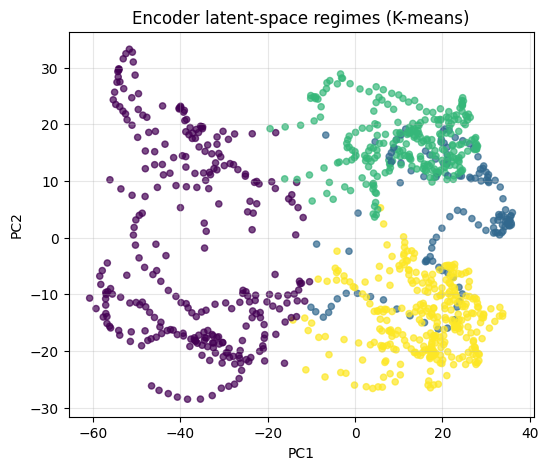

In [194]:
plt.figure(figsize=(6, 5))
plt.scatter(
    X_e_roll_pca[:, 0],
    X_e_roll_pca[:, 1],
    c=regime_e,
    s=20,
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Encoder latent-space regimes (K-means)")
plt.grid(True, alpha=0.3)
plt.show()